# Lab 1: Linear Regression & Logistic Regression (Beginner Guide)

**Goal:** By the end of this lab, you will understand:
- The difference between **Linear Regression** and **Logistic Regression**
- What **train/test split** means and why we do it
- How to train, test, and evaluate a model using **scikit-learn (sklearn)**

**Rule of thumb (in simple words):**
- Linear Regression → predicts a **number** (e.g. Salary, Price, Yield in tons)
- Logistic Regression → predicts a **category / Yes-No answer** (e.g. Will this patient have diabetes? Yes or No)

We will do TWO mini-projects in this notebook:
1. **Linear Regression** — Predict Salary from Years of Experience
2. **Logistic Regression** — Predict whether a patient has Diabetes (Yes/No) from medical data


## Step 0: Import the libraries we need

- `pandas` → to load and look at data (like Excel, but in code)
- `matplotlib` → to draw graphs
- `sklearn` → the machine learning library that gives us the models, the train/test split, and evaluation tools


In [1]:
# Run this cell first (installs quietly if something is missing)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_absolute_error, r2_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

print("All libraries loaded successfully!")


All libraries loaded successfully!


---
# PART 1 — Linear Regression

### What is Linear Regression? (Simple words)

Imagine you know how many **years of experience** an employee has, and you want to guess their **salary**.

Linear Regression tries to draw the **best straight line** through the data points, so that:

`Salary ≈ (slope × Years of Experience) + starting_point`

Once we have that line, we can plug in a NEW number of years and get a predicted salary — even for someone not in our original data.

### The Dataset
We will use a small, well-known beginner dataset: **Salary vs Years of Experience** (30 rows, 2 columns).

Source CSV (loaded directly from the internet, no download needed):
`https://raw.githubusercontent.com/krishnaik06/simple-Linear-Regression/master/Salary_Data.csv`


In [2]:
# Step 1: Load the dataset directly from the internet using pandas
url = "https://raw.githubusercontent.com/krishnaik06/simple-Linear-Regression/master/Salary_Data.csv"
salary_df = pd.read_csv(url)

# Let's peek at the first 5 rows
salary_df.head()


,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [ ]:
# Step 2: Quick look at the data
print("Shape of data (rows, columns):", salary_df.shape)
print()
print(salary_df.describe())  # basic statistics: mean, min, max, etc.


Shape of data (rows, columns): (30, 3)

       YearsExperience         Salary  Education
count        30.000000      30.000000  30.000000
mean          5.313333   76003.000000  15.566667
std           2.837888   27414.429785   2.207875
min           1.100000   37731.000000  12.000000
25%           3.200000   56720.750000  13.250000
50%           4.700000   65237.000000  16.000000
75%           7.700000  100544.750000  17.000000
max          10.500000  122391.000000  19.000000


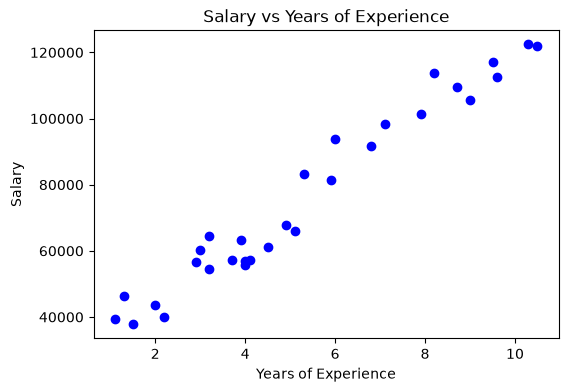

In [4]:
# Step 3: Visualize the data before doing anything else
# This helps us SEE if a straight line even makes sense here
plt.figure(figsize=(6,4))
plt.scatter(salary_df["YearsExperience"], salary_df["Salary"], color="blue")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Salary vs Years of Experience")
plt.show()


### Step 4: What is `train_test_split`? (Simple words)

Before training our model, we must split our data into TWO parts:

| Part | Purpose | Typical size |
|---|---|---|
| **Training set** | The model *learns* the pattern from this part | ~80% |
| **Testing set** | We *hide* this part from the model during training, then use it at the end to check "did the model actually learn, or did it just memorize?" | ~20% |

**Why do we do this?**
Think of it like studying for an exam. If you only ever practice the exact same 10 questions and then get tested on those same 10 questions, you don't really know if you *understood* the topic — you might have just memorized the answers.

The **test set** acts like "new, unseen questions" — it tells us how well our model will perform on real, new data it has never seen before.

We use `train_test_split` from sklearn to do this split randomly and fairly.


In [5]:
# Step 4: Split data into features (X) and target (y)
# X = the input(s) we use to predict.  y = the value we want to predict.
X = salary_df[["YearsExperience"]]   # double brackets = keep it as a table (DataFrame)
y = salary_df["Salary"]              # single bracket = a simple column (Series)

# Now split into training data and testing data
# test_size=0.2 means: 20% of the data goes to testing, 80% goes to training
# random_state=42 just makes the split reproducible (same split every time you run it)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training rows:", X_train.shape[0])
print("Testing rows :", X_test.shape[0])


Training rows: 24
Testing rows : 6


### Step 5: Train the Linear Regression model

`model.fit(X_train, y_train)` is the line that actually does the "learning".
Sklearn finds the best straight line that fits the training data.


In [6]:
# Step 5: Create and train the model
model = LinearRegression()
model.fit(X_train, y_train)   # <-- this is where the "learning" happens

print("Learned slope (coefficient):", model.coef_[0])
print("Learned intercept (starting point):", model.intercept_)


Learned slope (coefficient): 9423.815323030976
Learned intercept (starting point): 25321.583011776813


### Step 6: Make predictions on the TEST set

Remember: the model has never seen `X_test` during training. This is the fair test.


In [7]:
# Step 6: Predict salaries for the test set
y_pred = model.predict(X_test)

# Let's compare actual vs predicted side-by-side
comparison_df = pd.DataFrame({
    "Actual Salary": y_test.values,
    "Predicted Salary": y_pred.round(2)
})
comparison_df


,Actual Salary,Predicted Salary
0,112635.0,115790.21
1,67938.0,71498.28
2,113812.0,102596.87
3,83088.0,75267.80
4,64445.0,55477.79
5,57189.0,60189.70


### Step 7: Evaluate the model (how good are the predictions?)

Two simple beginner-friendly metrics:

- **Mean Absolute Error (MAE)** → on average, how far off (in dollars) is our prediction from the real value? Lower is better.
- **R² Score (R-squared)** → a score between 0 and 1 (roughly) that tells us how much of the pattern in the data our line explains. Closer to 1 = better fit.


In [8]:
# Step 7: Evaluate
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae:.2f}  (on average, predictions are off by this much)")
print(f"R2 Score: {r2:.3f}  (1.0 = perfect fit, 0 = no better than guessing the average)")


Mean Absolute Error: 6286.45  (on average, predictions are off by this much)
R2 Score: 0.902  (1.0 = perfect fit, 0 = no better than guessing the average)


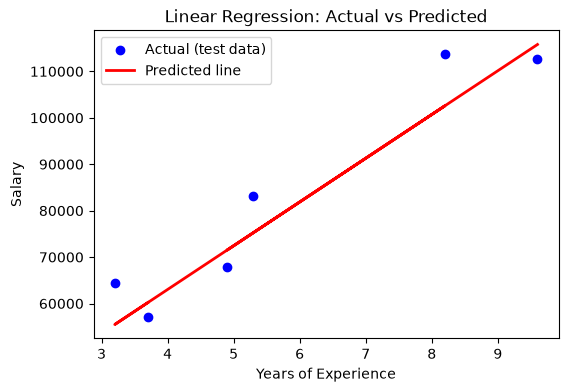

In [9]:
# Step 8: Visualize the regression line against the TEST data
plt.figure(figsize=(6,4))
plt.scatter(X_test, y_test, color="blue", label="Actual (test data)")
plt.plot(X_test, y_pred, color="red", linewidth=2, label="Predicted line")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Linear Regression: Actual vs Predicted")
plt.legend()
plt.show()


### Step 9: Predict for a brand-new employee

Let's say a new candidate has **7.5 years** of experience. What salary does our model predict?


In [10]:
new_experience = pd.DataFrame({"YearsExperience": [7.5]})
predicted_salary = model.predict(new_experience)
print(f"Predicted salary for 7.5 years of experience: {predicted_salary[0]:.2f}")


Predicted salary for 7.5 years of experience: 96000.20


### 🎯 Part 1 Recap
- We loaded real data with `pandas`
- We split it with `train_test_split` (80% train / 20% test)
- We trained a `LinearRegression` model
- We evaluated it with MAE and R²
- We used it to predict a brand-new value

Now let's move to a problem where the answer is **Yes/No** instead of a number.


---
# PART 2 — Logistic Regression

### What is Logistic Regression? (Simple words)

Logistic Regression is used when the answer is a **category**, most commonly **Yes/No** (also called binary classification).

Examples:
- Will this patient have diabetes? (Yes / No)
- Will this crop have a pest attack? (Yes / No)
- Is this email spam? (Yes / No)

Even though it has "regression" in the name, logistic regression is actually a **classification** algorithm.

**How does it work (intuition)?**
Instead of drawing a straight line like Linear Regression, Logistic Regression draws an **S-shaped curve** (called a sigmoid curve) that squashes any input into a probability between 0 and 1. If that probability is above 0.5, we predict "Yes" (1); otherwise "No" (0).

### The Dataset: Pima Indians Diabetes Dataset

768 patients, 8 medical measurements (Glucose level, BMI, Age, etc.), and 1 target column `Outcome`:
- `Outcome = 1` → patient has diabetes
- `Outcome = 0` → patient does not have diabetes

Source CSV (loaded directly from the internet, no download needed):
`https://raw.githubusercontent.com/npradaschnor/Pima-Indians-Diabetes-Dataset/master/diabetes.csv`


In [11]:
# Step 1: Load the diabetes dataset
diabetes_url = "https://raw.githubusercontent.com/npradaschnor/Pima-Indians-Diabetes-Dataset/master/diabetes.csv"
diabetes_df = pd.read_csv(diabetes_url)

diabetes_df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [12]:
# Step 2: Quick look
print("Shape:", diabetes_df.shape)
print()
print("How many patients have diabetes (1) vs not (0)?")
print(diabetes_df["Outcome"].value_counts())


Shape: (768, 9)

How many patients have diabetes (1) vs not (0)?
Outcome
0    500
1    268
Name: count, dtype: int64


### Step 3: Features (X) and Target (y)

- `X` = all the medical measurement columns (everything except `Outcome`)
- `y` = the `Outcome` column (the thing we want to predict: 0 or 1)


In [13]:
X = diabetes_df.drop(columns=["Outcome"])
y = diabetes_df["Outcome"]

X.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33


### Step 4: Train/Test Split (again!)

Same idea as before — we hide 20% of the patients from the model so we can fairly test it afterwards.

One extra parameter here: `stratify=y`. In simple words — this makes sure both the training set AND the testing set have a similar percentage of "Yes" and "No" cases, so the split is fair and balanced.


In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # keeps the Yes/No ratio similar in both train and test sets
)

print("Training rows:", X_train.shape[0])
print("Testing rows :", X_test.shape[0])


Training rows: 614
Testing rows : 154


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y   # keeps the Yes/No ratio similar in both train and test sets
)

print("Training rows:", X_train.shape[0])
print("Testing rows :", X_test.shape[0])


Training rows: 537
Testing rows : 231


### Step 5: Train the Logistic Regression model

Same pattern as Linear Regression: create the model, then call `.fit()`.

We add `max_iter=1000` because this dataset sometimes needs a few more calculation rounds to fully converge (settle on an answer) — this is a common beginner fix, not something to worry about deeply.


In [26]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

print("Model trained!")


Model trained!


### Step 6: Predict on the test set

In [27]:
y_pred = log_model.predict(X_test)

# Compare a handful of actual vs predicted values
comparison_df = pd.DataFrame({
    "Actual": y_test.values[:10],
    "Predicted": y_pred[:10]
})
comparison_df


,Actual,Predicted
0,0,1
1,0,0
2,0,0
3,1,0
4,0,0
5,0,0
6,1,0
7,1,1
8,0,0
9,0,1


### Step 7: Evaluate the model

- **Accuracy** → out of all predictions, what percentage did we get right? (Simple, but can be misleading if classes are imbalanced.)
- **Confusion Matrix** → a table showing exactly how many predictions were correct/incorrect, broken down by class:
    - **True Positive** — predicted "Yes", actually "Yes" ✅
    - **True Negative** — predicted "No", actually "No" ✅
    - **False Positive** — predicted "Yes", actually "No" ❌
    - **False Negative** — predicted "No", actually "Yes" ❌


Accuracy: 71.43%
r2 score will be :  -0.2548148148148148


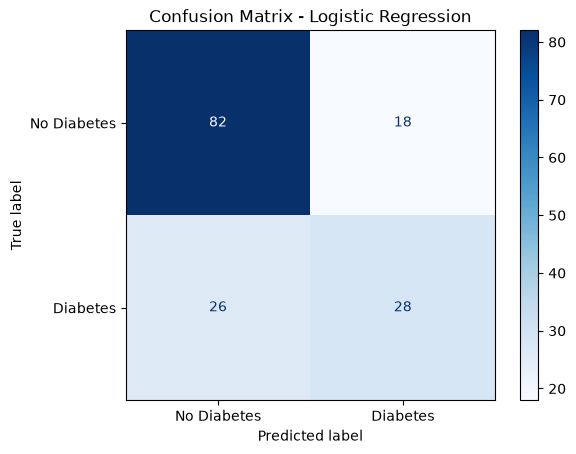

In [28]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2%}")

r2=r2_score(y_test,y_pred)
print("r2 score will be : ",r2)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Diabetes", "Diabetes"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()


### Step 8: Predict for a brand-new patient

Let's make up one new patient with some medical readings and see what the model predicts.

Column order must match the training data: `Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age`


In [19]:
new_patient = pd.DataFrame([{
    "Pregnancies": 2,
    "Glucose": 150,
    "BloodPressure": 80,
    "SkinThickness": 30,
    "Insulin": 100,
    "BMI": 32.5,
    "DiabetesPedigreeFunction": 0.5,
    "Age": 45
}])

prediction = log_model.predict(new_patient)[0]
probability = log_model.predict_proba(new_patient)[0][1]  # probability of class "1" (has diabetes)

result = "Diabetes" if prediction == 1 else "No Diabetes"
print(f"Prediction: {result}")
print(f"Probability of diabetes: {probability:.2%}")


Prediction: Diabetes
Probability of diabetes: 53.22%


# Changing The Values In New Patient (For Change in Prediction)

In [64]:
new_patient = pd.DataFrame([{
    "Pregnancies": 2,
    "Glucose": 120,
    "BloodPressure": 70,
    "SkinThickness": 50,
    "Insulin": 110,
    "BMI": 27.5,
    "DiabetesPedigreeFunction": 0.8,
    "Age": 27
}])

prediction = log_model.predict(new_patient)[0]
probability = log_model.predict_proba(new_patient)[0][1]  # probability of class "1" (has diabetes)

result = "Diabetes" if prediction == 1 else "No Diabetes"
print(f"Prediction: {result}")
print(f"Probability of diabetes: {probability:.2%}")


Prediction: No Diabetes
Probability of diabetes: 17.38%


### 🎯 Part 2 Recap
- We loaded a real medical dataset
- We split it into train/test (with `stratify` to keep the split balanced)
- We trained a `LogisticRegression` model
- We evaluated it with **accuracy** and a **confusion matrix**
- We used it to predict on a brand-new patient

---
## Final Summary: Linear vs Logistic Regression

| | Linear Regression | Logistic Regression |
|---|---|---|
| Predicts | A number (e.g. salary) | A category (e.g. Yes/No) |
| Output shape | Straight line | S-shaped curve (sigmoid) |
| Example metric | MAE, R² | Accuracy, Confusion Matrix |
| Sklearn class | `LinearRegression` | `LogisticRegression` |

**Try it yourself:**
1. Change `test_size` to 0.3 in either lab — does accuracy/R² change much?
2. In Part 1, try adding a second feature to `X` (if the dataset had one) and see how predictions change.
3. In Part 2, try changing the values in `new_patient` and see how the prediction changes.


# For Accuracy/R2 Score Change

In [30]:
# Step 1: Load the diabetes dataset
diabetes_url = "https://raw.githubusercontent.com/npradaschnor/Pima-Indians-Diabetes-Dataset/master/diabetes.csv"
diabetes_df = pd.read_csv(diabetes_url)

diabetes_df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


### Step 3: Features (X) and Target (y)

- `X` = all the medical measurement columns (everything except `Outcome`)
- `y` = the `Outcome` column (the thing we want to predict: 0 or 1)


In [31]:
X = diabetes_df.drop(columns=["Outcome"])
y = diabetes_df["Outcome"]

X.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33


In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y   # keeps the Yes/No ratio similar in both train and test sets
)

print("Training rows:", X_train.shape[0])
print("Testing rows :", X_test.shape[0])


Training rows: 537
Testing rows : 231


In [33]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

print("Model trained!")


Model trained!


In [34]:
y_pred = log_model.predict(X_test)

# Compare a handful of actual vs predicted values
comparison_df = pd.DataFrame({
    "Actual": y_test.values[:10],
    "Predicted": y_pred[:10]
})
comparison_df


,Actual,Predicted
0,1,0
1,1,0
2,1,1
3,1,1
4,1,0
5,0,0
6,0,1
7,0,0
8,0,0
9,0,0


Accuracy: 74.03%
r2 score will be :  -0.1407407407407406


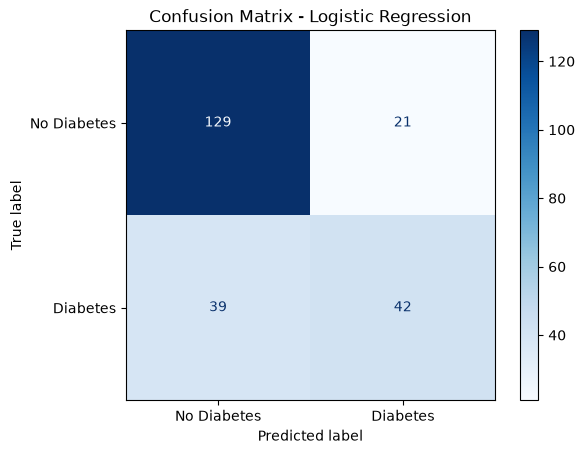

In [35]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2%}")

r2=r2_score(y_test,y_pred)
print("r2 score will be : ",r2)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Diabetes", "Diabetes"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()


In [ ]:
new_patient = pd.DataFrame([{
    "Pregnancies": 2,
    "Glucose": 150,
    "BloodPressure": 80,
    "SkinThickness": 30,
    "Insulin": 100,
    "BMI": 32.5,
    "DiabetesPedigreeFunction": 0.5,
    "Age": 45
}])

prediction = log_model.predict(new_patient)[0]
probability = log_model.predict_proba(new_patient)[0][1]  # probability of class "1" (has diabetes)

result = "Diabetes" if prediction == 1 else "No Diabetes"
print(f"Prediction: {result}")
print(f"Probability of diabetes: {probability:.2%}")


Prediction: Diabetes
Probability of diabetes: 53.22%


# Adding Another Feature X in Part 1

In [37]:
salary_df.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [39]:
# This creates a random number between 12 and 20 for exactly the length of your dataset
salary_df["Education"] = np.random.randint(12, 20, size=len(salary_df))

In [41]:
salary_df.head()

,YearsExperience,Salary,Education
0,1.1,39343.0,17
1,1.3,46205.0,14
2,1.5,37731.0,17
3,2.0,43525.0,16
4,2.2,39891.0,18


In [43]:
# Step 2: Quick look at the data
print("Shape of data (rows, columns):", salary_df.shape)
print()
print(salary_df.describe())  # basic statistics: mean, min, max, etc.


Shape of data (rows, columns): (30, 3)

       YearsExperience         Salary  Education
count        30.000000      30.000000  30.000000
mean          5.313333   76003.000000  15.566667
std           2.837888   27414.429785   2.207875
min           1.100000   37731.000000  12.000000
25%           3.200000   56720.750000  13.250000
50%           4.700000   65237.000000  16.000000
75%           7.700000  100544.750000  17.000000
max          10.500000  122391.000000  19.000000


In [59]:
# Step 4: Split data into features (X) and target (y)
# X = the input(s) we use to predict.  y = the value we want to predict.
X = salary_df[["YearsExperience","Education"]]   # double brackets = keep it as a table (DataFrame)
y = salary_df["Salary"]              # single bracket = a simple column (Series)

# Now split into training data and testing data
# test_size=0.2 means: 20% of the data goes to testing, 80% goes to training
# random_state=42 just makes the split reproducible (same split every time you run it)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training rows:", X_train.shape[0])
print("Testing rows :", X_test.shape[0])


Training rows: 24
Testing rows : 6


In [60]:
# Step 5: Create and train the model
model = LinearRegression()
model.fit(X_train, y_train)   # <-- this is where the "learning" happens

print("Learned slope (coefficient):", model.coef_[0])
print("Learned intercept (starting point):", model.intercept_)


Learned slope (coefficient): 9389.107731413455
Learned intercept (starting point): 31757.27470850615


In [61]:
# Step 6: Predict salaries for the test set
y_pred = model.predict(X_test)

# Let's compare actual vs predicted side-by-side
comparison_df = pd.DataFrame({
    "Actual Salary": y_test.values,
    "Predicted Salary": y_pred.round(2)
})
comparison_df


,Actual Salary,Predicted Salary
0,112635.0,115871.23
1,67938.0,71340.99
2,113812.0,103529.34
3,83088.0,75096.64
4,64445.0,55780.94
5,57189.0,59271.20


So, Yes there is some difference in predicted salary when we add a new feature 'X'